In [ ]:
# 1. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

import pyodbc


In [ ]:
# 2. Kết nối DDS
SERVER = r"DESKTOP-QDDK8KF\INSTANCE22127366"
DB = "BI_Proj_Airlines_DDS"

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={SERVER};"
    f"DATABASE={DB};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

cn = pyodbc.connect(conn_str)

# 3. Query các chuyến bay bị delay hơn 15p
query = """
SELECT
    -- TARGET
    f.DelayOver15_Flag,

    -- DATE FEATURES
    d.Year,
    d.Quarter,
    d.Month,
    d.WeekOfYear,
    d.IsWeekend,
    d.Season,

    -- TIME FEATURES
    t_dep.HourOfDay AS Scheduled_Dep_Hour,
    t_arr.HourOfDay AS Scheduled_Arr_Hour,

    -- AIRLINE
    al.Airline_NK,

    -- ORIGIN AIRPORT
    ap_o.City       AS Origin_City,
    ap_o.StateProv AS Origin_State,
    ap_o.Country   AS Origin_Country,

    -- DEST AIRPORT
    ap_d.City       AS Dest_City,
    ap_d.StateProv AS Dest_State,
    ap_d.Country   AS Dest_Country,

    -- FLIGHT FEATURES
    f.Distance,
    f.Scheduled_Time

FROM Fact_Flights f
JOIN Dim_Date d ON f.Date_SK = d.Date_SK

LEFT JOIN Dim_Time t_dep ON f.Scheduled_Departure_SK = t_dep.Time_SK
LEFT JOIN Dim_Time t_arr ON f.Scheduled_Arrival_SK = t_arr.Time_SK

LEFT JOIN Dim_Airlines al ON f.Airline_SK = al.Airline_SK
LEFT JOIN Dim_Airports ap_o ON f.Origin_Airport_SK = ap_o.Airport_SK
LEFT JOIN Dim_Airports ap_d ON f.Destination_Airport_SK = ap_d.Airport_SK
"""

df = pd.read_sql(query, cn)

print("Kích thước dữ liệu:", df.shape)
df.head()



C:\Users\Pearson\AppData\Local\Temp\ipykernel_9000\3323289215.py:61: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cn)


Kích thước dữ liệu: (104067, 18)


,DelayOver15_Flag,Year,Quarter,Month,WeekOfYear,IsWeekend,Season,Scheduled_Dep_Hour,Scheduled_Arr_Hour,Airline_NK,Origin_City,Origin_State,Origin_Country,Dest_City,Dest_State,Dest_Country,Distance,Scheduled_Time
0,False,2015,3,8,33,False,Summer,15,19,AA,Dallas-Fort Worth,TX,USA,Baltimore,MD,USA,1217,190
1,False,2015,3,8,33,False,Summer,15,19,AA,Dallas-Fort Worth,TX,USA,Baltimore,MD,USA,1217,190
2,False,2015,3,8,34,False,Summer,15,19,AA,Dallas-Fort Worth,TX,USA,Baltimore,MD,USA,1217,190
3,False,2015,3,8,33,False,Summer,15,19,AA,Dallas-Fort Worth,TX,USA,Baltimore,MD,USA,1217,190
4,True,2015,3,8,33,False,Summer,15,19,AA,Dallas-Fort Worth,TX,USA,Baltimore,MD,USA,1217,190


In [ ]:
# 4. EDA
print(df.info())

print("\nPhân phối biến mục tiêu:")
print(df["DelayOver15_Flag"].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104067 entries, 0 to 104066
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   DelayOver15_Flag    104067 non-null  bool  
 1   Year                104067 non-null  int64 
 2   Quarter             104067 non-null  int64 
 3   Month               104067 non-null  int64 
 4   WeekOfYear          104067 non-null  int64 
 5   IsWeekend           104067 non-null  bool  
 6   Season              104067 non-null  object
 7   Scheduled_Dep_Hour  104067 non-null  int64 
 8   Scheduled_Arr_Hour  104067 non-null  int64 
 9   Airline_NK          104067 non-null  object
 10  Origin_City         104067 non-null  object
 11  Origin_State        104067 non-null  object
 12  Origin_Country      104067 non-null  object
 13  Dest_City           104067 non-null  object
 14  Dest_State          104067 non-null  object
 15  Dest_Country        104067 non-null  object
 16  Di

In [ ]:
# 5. Chuẩn bị dữ liệu cho Supervised Learning
y = df["DelayOver15_Flag"].astype(int)
X = df.drop(columns=["DelayOver15_Flag"])


numeric_features = [
    "Year", "Quarter", "Month", "WeekOfYear",
    "Scheduled_Dep_Hour", "Scheduled_Arr_Hour",
    "Distance", "Scheduled_Time"
]

categorical_features = [
    "Season",
    "Airline_NK",
    "Origin_City", "Origin_State", "Origin_Country",
    "Dest_City", "Dest_State", "Dest_Country"
]

binary_features = ["IsWeekend"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

DelayOver15_Flag
0    81724
1    22343
Name: count, dtype: int64
DelayOver15_Flag
0    0.785302
1    0.214698
Name: proportion, dtype: float64


In [ ]:
# 6. Hàm đánh giá mô hình
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC – {name}")
    plt.legend()
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": roc_auc
    }



Logistic Regression
Accuracy : 0.6111
Precision: 0.3023
Recall   : 0.6203
F1       : 0.4065
              precision    recall  f1-score   support

           0       0.85      0.61      0.71     16345
           1       0.30      0.62      0.41      4469

    accuracy                           0.61     20814
   macro avg       0.58      0.61      0.56     20814
weighted avg       0.74      0.61      0.65     20814



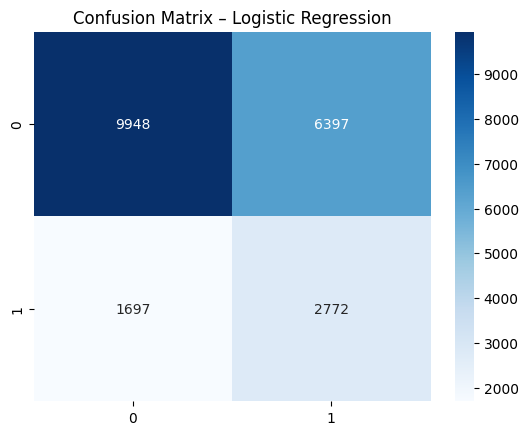

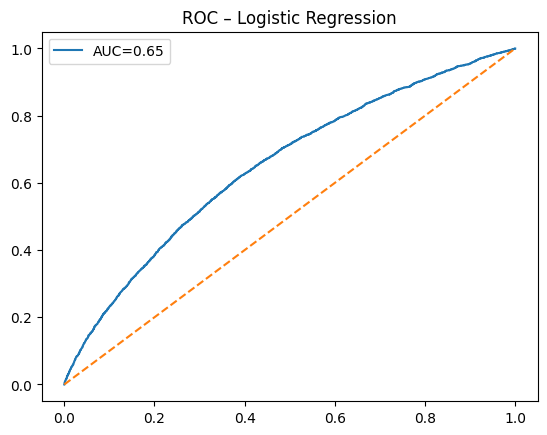


Decision Tree
Accuracy : 0.6234
Precision: 0.2907
Recall   : 0.5236
F1       : 0.3739
              precision    recall  f1-score   support

           0       0.83      0.65      0.73     16345
           1       0.29      0.52      0.37      4469

    accuracy                           0.62     20814
   macro avg       0.56      0.59      0.55     20814
weighted avg       0.72      0.62      0.65     20814



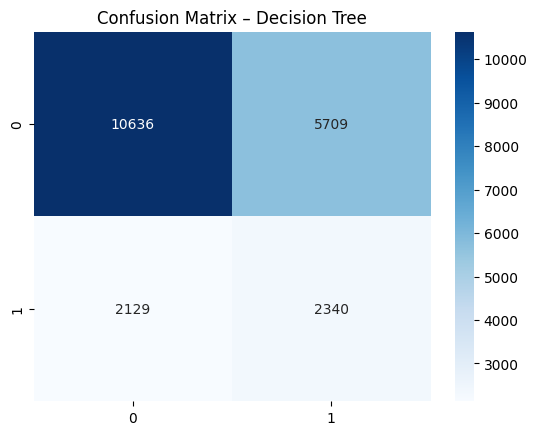

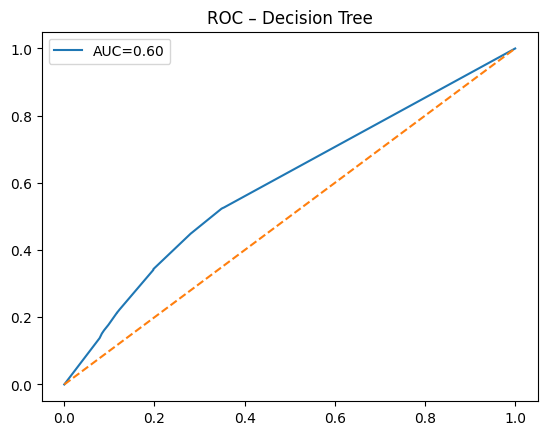

In [ ]:
# 7. Logistic Regression
pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)
res_lr = evaluate_model(pipe_lr, X_test, y_test, "Logistic Regression")


# 8. Decision Tree
pipe_dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="entropy",
        class_weight="balanced",
        random_state=42
    ))
])

pipe_dt.fit(X_train, y_train)
res_dt = evaluate_model(pipe_dt, X_test, y_test, "Decision Tree")

# Lấy danh sách feature sau preprocessing
feature_names = (
    pipe_lr.named_steps["prep"]
    .get_feature_names_out()
)




                     Accuracy  Precision    Recall        F1       AUC
Model                                                                 
Logistic Regression  0.611127   0.302323  0.620273  0.406511  0.650367
Decision Tree        0.623427   0.290719  0.523607  0.373862  0.596520


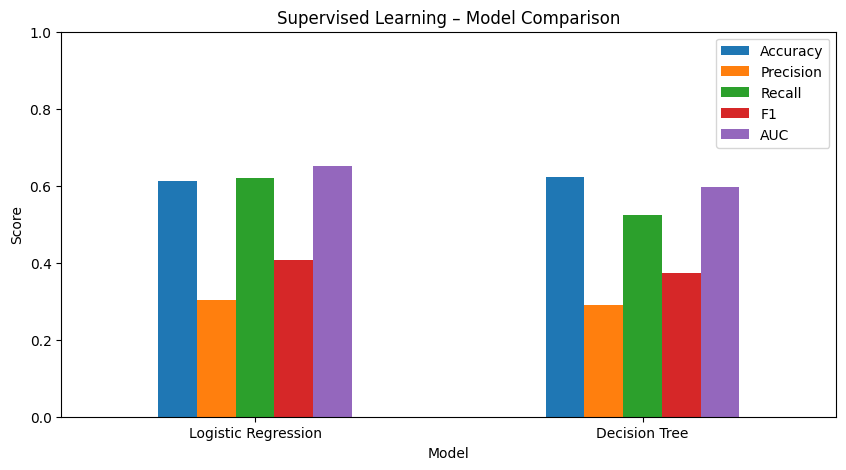

In [ ]:
# 9. So sánh kết quả 2 mô hình
results_df = pd.DataFrame([res_lr, res_dt]).set_index("Model")
print(results_df)

results_df.plot(kind="bar", figsize=(10,5), rot=0)
plt.title("Supervised Learning – Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

## Report
2 mô hình Logistic Regression và Decision Tree được huấn luyện và đánh giá dựa trên các feature có được trước giờ bay

### Logistic Regression
- Accuracy: **0.611**
- Precision (delay): **0.302**
- Recall (delay): **0.620**
- F1-score (delay): **0.407**
- AUC: **~0.65**

Mô hình Logistic Regression đạt Recall cao nhất đối với lớp delay, cho thấy khả năng **phát hiện phần lớn các chuyến bay có nguy cơ trễ**, dù Precision còn thấp do dữ liệu mất cân bằng. AUC tương đối tốt cho thấy khả năng phân biệt hai lớp ở mức chấp nhận được.

---

### Decision Tree
- Accuracy: **0.623**
- Precision (delay): **0.291**
- Recall (delay): **0.524**
- F1-score (delay): **0.374**
- AUC: **~0.60**

Decision Tree đạt Accuracy cao hơn nhưng Recall thấp hơn Logistic Regression, nghĩa là mô hình **bỏ sót nhiều chuyến bay bị delay hơn**. Tuy nhiên, Decision Tree có ưu điểm lớn về **khả năng diễn giải**, thông qua phân tích feature importance để xác định các yếu tố ảnh hưởng đến delay.

---

### So sánh và lựa chọn mô hình

Trong bối cảnh hệ thống BI cho hàng không, mục tiêu chính là **cảnh báo sớm rủi ro delay** để hỗ trợ vận hành và ra quyết định. Do đó, việc ưu tiên Recall cao để giảm thiểu bỏ sót các chuyến bay bị trễ là quan trọng hơn so với tối ưu Accuracy.

=> **Logistic Regression được lựa chọn làm mô hình dự đoán chính**, nhờ khả năng phát hiện delay tốt hơn và AUC cao hơn.  

In [ ]:
# 10. Xem xét các yếu tố ảnh hưởng mạnh/yếu đến khả năng delay (Logistic Regression)
coefficients = pipe_lr.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values("Abs_Coefficient", ascending=False)

coef_df.head(15)




,Feature,Coefficient,Abs_Coefficient
13,cat__Airline_NK_DL,-1.388044,1.388044
2,num__Month,0.771914,0.771914
3,num__WeekOfYear,-0.675571,0.675571
16,cat__Airline_NK_NK,0.648265,0.648265
20,cat__Airline_NK_WN,0.559192,0.559192
17,cat__Airline_NK_OO,0.287123,0.287123
47,bin__IsWeekend,-0.278515,0.278515
4,num__Scheduled_Dep_Hour,0.277381,0.277381
19,cat__Airline_NK_US,-0.244174,0.244174
1,num__Quarter,-0.234569,0.234569


In [ ]:
# 11. Demo dự đoán cho 1 chuyến bay mới
new_flight = pd.DataFrame([{
    "Year": 2015,
    "Quarter": 3,
    "Month": 7,
    "WeekOfYear": 29,
    "IsWeekend": False,
    "Season": "Summer",
    "Scheduled_Dep_Hour": 18,
    "Scheduled_Arr_Hour": 21,
    "Airline_NK": "AA",
    "Origin_City": "Chicago",
    "Origin_State": "IL",
    "Origin_Country": "USA",
    "Dest_City": "Dallas-Fort Worth",
    "Dest_State": "TX",
    "Dest_Country": "USA",
    "Distance": 802,
    "Scheduled_Time": 150,
    "Diverted": False,
    "Cancelled": False
}])

# Dự đoán bằng mô hình Decision Tree
pred = pipe_lr.predict(new_flight)[0]
prob = pipe_lr.predict_proba(new_flight)[0][1]

print("Delay Prediction (1 = Delay > 15 phút):", pred)
print(f"Delay Probability: {prob:.2%}")



Delay Prediction (1 = Delay > 15 phút): 1
Delay Probability: 62.43%


### Unsupervised Learning

In [ ]:
# 12. Chuẩn bị dữ liệu cho Unsupervised learning
airport_df = df.groupby("Origin_City").agg(
    total_flights=("DelayOver15_Flag", "count"),
    delay_rate=("DelayOver15_Flag", "mean"),
).reset_index()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    airport_df[["total_flights", "delay_rate"]]
)

airport_df.head(5)

,Origin_City,total_flights,delay_rate
0,Baltimore,7807,0.204688
1,Charlotte,19587,0.217695
2,Chicago,28006,0.241841
3,Dallas-Fort Worth,20608,0.209191
4,New York,17505,0.192288


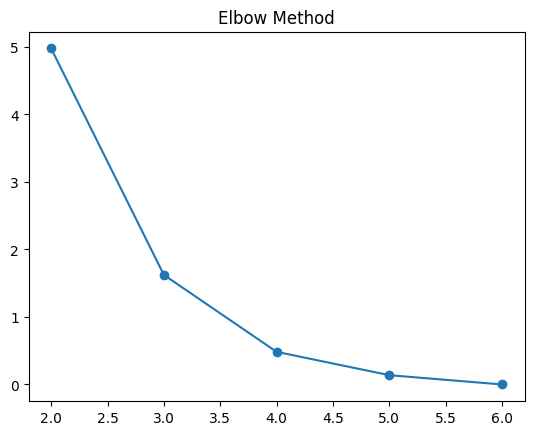

,total_flights,delay_rate
Cluster,,
0,28006.000000,0.241841
1,19233.333333,0.206391
2,9180.500000,0.198563


In [ ]:
# K-MEANS
wss = []
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wss.append(km.inertia_)

plt.plot(range(2,7), wss, marker="o")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
airport_df["Cluster"] = kmeans.fit_predict(X_scaled)

airport_df.groupby("Cluster")[["total_flights","delay_rate"]].mean()


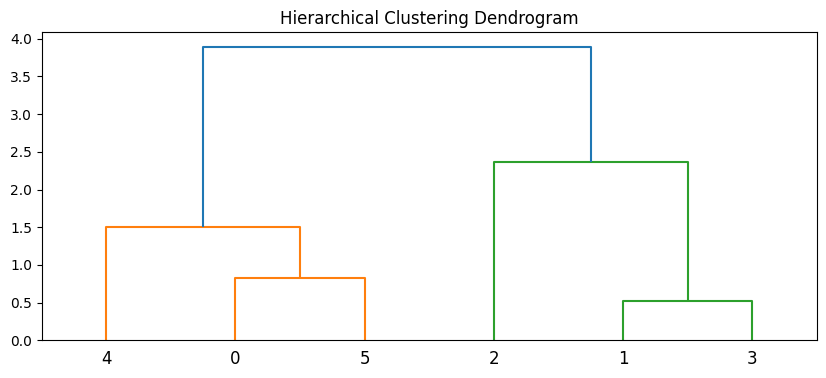

In [ ]:
# 13. Hierarchical
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10,4))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()


## Unsupervised Learning – Clustering

### K-Means Clustering
Dữ liệu được tổng hợp theo **sân bay xuất phát**, gồm tổng số chuyến bay, tỷ lệ trễ.
Sử dụng **Elbow Method**, số cụm phù hợp được chọn là **K = 3**.

Kết quả cho thấy:
- **Cluster 0**: Có **lưu lượng chuyến bay rất lớn** và **tỷ lệ delay cao nhất** (~24.2%). Đây là nhóm sân bay có **rủi ro vận hành cao**, cần được ưu tiên giám sát và tối ưu quy trình khai thác.
- **Cluster 1**: Lưu lượng chuyến bay ở mức **trung bình–cao** với **tỷ lệ delay trung bình** (~20.6%). Nhóm này có mức độ ổn định tương đối nhưng vẫn tiềm ẩn rủi ro trong các giai đoạn cao điểm.
- **Cluster 2**: Có **lưu lượng chuyến bay thấp nhất** và **tỷ lệ delay thấp nhất** (~19.9%). Đây là nhóm sân bay **ổn định**, ít gây áp lực vận hành và phù hợp làm chuẩn tham chiếu.

Phân cụm giúp xác định các sân bay có mức độ rủi ro trễ chuyến khác nhau.

---

### Hierarchical Clustering
Biểu đồ dendrogram thể hiện quá trình **gom cụm phân cấp (Hierarchical Clustering – Ward linkage)** giữa các sân bay dựa trên mức độ tương đồng về hành vi delay.

- **Trục dọc** biểu diễn khoảng cách (độ khác biệt) giữa các cụm: khoảng cách càng lớn → các cụm càng khác nhau.
- Các sân bay/cụm được **gom lại từ dưới lên**, bắt đầu từ những đối tượng giống nhau nhất.
- Khi cắt dendrogram ở một ngưỡng khoảng cách phù hợp (trước điểm nhảy lớn), dữ liệu **tự nhiên chia thành 3 cụm**.

Kết quả này **nhất quán với K-Means (K = 3)**, xác nhận rằng việc lựa chọn 3 cluster là hợp lý và phản ánh cấu trúc thực sự của dữ liệu. Hierarchical clustering đóng vai trò kiểm chứng, giúp tăng độ tin cậy cho kết quả phân cụm trong phân tích BI.


